# Tema 1. Introducción a Python para predicción: de los datos a la regresión lineal

**Técnicas Avanzadas de Predicción en Negocios**

Datos: Encuesta Cuatrienal de Estructura Salarial 2022 (INE), microdatos anonimizados.

## Qué vamos a hacer

Este cuaderno tiene dos propósitos a la vez. El primero es aprender a trabajar en Python con un conjunto de datos real: cargarlo, mirarlo, limpiarlo y dejarlo preparado para un modelo. El segundo es ajustar y evaluar el primer modelo del curso, la regresión lineal, que ya conocéis de R.

El cuaderno está pensado para quien viene de R y no ha usado Python. Cada vez que aparece una idea nueva de Python se explica antes de usarla, y cuando existe un equivalente directo en R se indica.

## Objetivos

Al terminar deberías ser capaz de:

1. Cargar un fichero de datos en Python con `pandas` y describirlo (dimensión, tipos de variable, valores ausentes).
2. Explicar qué variables del fichero pueden usarse como predictores y cuáles no, y por qué.
3. Separar los datos en entrenamiento y prueba, y explicar por qué se hace antes de cualquier otro paso.
4. Entender qué hacen `ColumnTransformer` y `Pipeline` de `scikit-learn` y por qué se usan.
5. Ajustar una regresión lineal, obtener predicciones y evaluarlas con medidas de error.

## Cómo trabajar con el cuaderno

Un cuaderno Jupyter se compone de celdas. Las celdas de texto (como esta) explican; las celdas de código se ejecutan con `Mayús + Intro` y muestran su resultado debajo. Ejecuta las celdas en orden, porque cada una usa objetos creados en las anteriores. Si algo falla, lo más frecuente es que falte ejecutar una celda anterior.

Hay ejercicios repartidos por el cuaderno, marcados como **Ejercicio**. Están pensados para hacerse en el momento, con lo visto hasta ese punto.

## 0. Preparación: librerías y datos

### 0.1 Librerías

En R se cargan paquetes con `library()`. En Python se hace con `import`. Hay tres formas habituales de escribirlo y conviene reconocerlas:

- `import pandas as pd`: carga la librería y le da un alias corto. Después se usa con el prefijo: `pd.read_csv(...)`.
- `from sklearn.linear_model import LinearRegression`: carga solo un objeto concreto de la librería, y se usa sin prefijo.
- `import matplotlib.pyplot as plt`: igual que el primero, pero de un submódulo.

Las librerías que usaremos en este cuaderno:

| Librería | Para qué sirve | Análogo en R |
|---|---|---|
| `pandas` | Tablas de datos (`DataFrame`) | `data.frame`, `dplyr` |
| `numpy` | Vectores y cálculo numérico | vectores y matrices base de R |
| `matplotlib`, `seaborn` | Gráficos | `ggplot2` |
| `scikit-learn` (`sklearn`) | Modelos de predicción y preprocesamiento | `lm()`, `caret`, `tidymodels` |

In [1]:
import warnings
warnings.filterwarnings("ignore")   # oculta avisos que no afectan a los resultados

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

sns.set_theme(style="whitegrid")
SEMILLA = 42   # fija los procesos aleatorios para que todos obtengamos los mismos resultados
print("Librerías cargadas")

Librerías cargadas


### 0.2 Cargar los datos

El fichero `EES_2022.tab` está publicado en la web del curso. `pd.read_csv()` es el equivalente de `read.csv()` o `read_delim()` en R, y acepta directamente una dirección web. El fichero del INE usa el tabulador como separador de columnas, por eso se indica `sep="\t"`. El resultado es un `DataFrame`, la tabla de datos de `pandas`.

In [2]:
URL_DATOS = "https://juandmontoro.github.io/tap/data/EES_2022.tab"

df = pd.read_csv(URL_DATOS, sep="\t", low_memory=False)
df.columns = [c.replace('"', "").strip() for c in df.columns]   # algunos nombres vienen entre comillas
print("Filas y columnas:", df.shape)

Filas y columnas: (240490, 56)


## 1. Primer vistazo a los datos

Antes de modelizar hay que mirar los datos. En la tabla siguiente están las operaciones básicas de `pandas` y su equivalente en R.

| Qué queremos | Python (`pandas`) | R |
|---|---|---|
| Dimensión | `df.shape` | `dim(df)` |
| Primeras filas | `df.head()` | `head(df)` |
| Tipos de cada columna | `df.dtypes` o `df.info()` | `str(df)` |
| Resumen numérico | `df.describe()` | `summary(df)` |
| Una columna | `df["SEXO"]` | `df$SEXO` |
| Varias columnas | `df[["SEXO", "ESTU"]]` | `df[, c("SEXO", "ESTU")]` |
| Filtrar filas | `df[df["SEXO"] == 1]` | `df[df$SEXO == 1, ]` |
| Tabla de frecuencias | `df["SEXO"].value_counts()` | `table(df$SEXO)` |

Una diferencia que conviene tener presente: en Python los índices empiezan en 0, no en 1.

In [3]:
df.head()

,IDENCCC,ORDENTRA,NUTS1,CNACE,ESTRATO2,CONTROL,MERCADO,REGULACION,SEXO,TIPOPAIS,...,DSIESPA3,SIESPA4,DSIESPA4,RETRINOIN,RETRIIN,GEXTRA,VESPNOIN,VESPIN,ANOS2,FACTOTAL
0,6,1,1,Q0,1,2,1,1,6,1,...,0,6,0,6615.01,1133.82,1644.48,0.0,0.0,4,17.55
1,6,2,1,Q0,1,2,1,1,6,1,...,0,6,0,30757.32,0.00,3965.28,0.0,0.0,5,17.55
2,6,3,1,Q0,1,2,1,1,1,1,...,0,6,0,7739.92,188.47,894.48,0.0,0.0,3,17.55
3,6,4,1,Q0,1,2,1,1,6,1,...,0,6,0,12407.11,191.71,0.00,0.0,0.0,3,17.55
4,6,5,1,Q0,1,2,1,1,6,1,...,0,6,0,19717.33,124.81,2633.76,0.0,0.0,3,17.55


In [4]:
# Tipos de columna y número de valores no ausentes en cada una
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240490 entries, 0 to 240489
Data columns (total 56 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDENCCC     240490 non-null  int64  
 1   ORDENTRA    240490 non-null  int64  
 2   NUTS1       240490 non-null  int64  
 3   CNACE       240490 non-null  object 
 4   ESTRATO2    240490 non-null  int64  
 5   CONTROL     240490 non-null  int64  
 6   MERCADO     240490 non-null  int64  
 7   REGULACION  240490 non-null  int64  
 8   SEXO        240490 non-null  int64  
 9   TIPOPAIS    240490 non-null  int64  
 10  CNO1        240490 non-null  object 
 11  RESPONSA    240490 non-null  int64  
 12  ESTU        240490 non-null  int64  
 13  ANOANTI     240490 non-null  int64  
 14  MESANTI     240490 non-null  int64  
 15  TIPOJOR     240490 non-null  int64  
 16  TIPOCON     240490 non-null  int64  
 17  FIJODISM    240490 non-null  int64  
 18  FIJODISD    240490 non-null  int64  
 19  VA

**Lectura.** Todas las columnas están completas (no hay valores ausentes) y `pandas` las ha leído como enteros o decimales. Esto no significa que todas sean numéricas en sentido estadístico: muchas son códigos de categorías (sexo, ocupación, comunidad autónoma) almacenados como números. Más adelante las trataremos como categóricas.

## 2. Las variables del fichero

Descripción de las 56 variables, tomada del diccionario oficial de la encuesta (`dr_EES_2022.xlsx`, distribuido junto con los microdatos).

Las variables monetarias están en euros con dos decimales; las mensuales se refieren al mes de octubre de 2022 y las anuales a todo el año 2022. "IT" significa incapacidad temporal (baja médica).

| Variable | Descripción | Tipo |
|---|---|---|
| IDENCCC | Código del centro de cotización (empresa) | identificador |
| ORDENTRA | Número de orden del trabajador dentro del centro | identificador |
| NUTS1 | Gran región geográfica (7 zonas) | categórica |
| CNACE | Actividad económica de la empresa (27 grupos de la CNAE) | categórica |
| ESTRATO2 | Tamaño de la empresa por número de trabajadores | categórica |
| CONTROL | Propiedad pública o privada | categórica |
| MERCADO | Ámbito del mercado al que sirve la empresa | categórica |
| REGULACION | Forma de regulación de las relaciones laborales (tipo de convenio) | categórica |
| SEXO | Sexo del trabajador | categórica |
| TIPOPAIS | Nacionalidad: España o resto del mundo | categórica |
| CNO1 | Grupo principal de ocupación (CNO-11, 17 grupos) | categórica |
| RESPONSA | Tiene responsabilidad de organización o supervisión | categórica |
| ESTU | Nivel de estudios (7 niveles) | categórica |
| ANOANTI | Años de antigüedad en la empresa | numérica |
| MESANTI | Meses de antigüedad, parte fraccionaria de la anterior | numérica |
| TIPOJOR | Tipo de jornada: completa o parcial | categórica |
| TIPOCON | Duración del contrato: indefinido o temporal | categórica |
| FIJODISM | Meses del periodo de trabajo del fijo discontinuo | numérica |
| FIJODISD | Días del periodo de trabajo del fijo discontinuo | numérica |
| VAL | Días de vacaciones anuales laborables | numérica |
| VAN | Días de vacaciones anuales naturales | numérica |
| PUENTES | Días de fiesta no oficiales | numérica |
| JAP | Jornada anual pactada (horas) | numérica |
| JSP1 | Jornada semanal pactada, horas | numérica |
| JSP2 | Jornada semanal pactada, minutos | numérica |
| HEXTRA | Horas extraordinarias | numérica |
| DRELABM | Días de relación laboral en octubre | numérica |
| SIESPM1 | Situación especial 1 en octubre (sí o no) | categórica |
| DSIESPM1 | Días en situación especial 1 en octubre | numérica |
| SIESPM2 | Situación especial 2 en octubre (sí o no) | categórica |
| DSIESPM2 | Días en situación especial 2 en octubre | numérica |
| SALBASE | Salario base de octubre | numérica |
| EXTRAORM | Paga extraordinaria cobrada en octubre | numérica |
| PHEXTRA | Pagos por horas extraordinarias en octubre | numérica |
| COMSAL | Complementos salariales de todo tipo en octubre | numérica |
| COMSALTT | Complementos por nocturnidad, turnos o fin de semana en octubre | numérica |
| IRPFMES | Retenciones de IRPF en octubre | numérica |
| COTIZA | Cotizaciones a la Seguridad Social en octubre | numérica |
| BASE | Base de cotización por contingencias comunes en octubre | numérica |
| DRELABAM | Duración de la relación laboral en el año, meses | numérica |
| DRELABAD | Duración de la relación laboral en el año, días | numérica |
| SIESPA1 | Situación especial 1 en el año (sí o no) | categórica |
| DSIESPA1 | Días en situación especial 1 en el año | numérica |
| SIESPA2 | Situación especial 2 en el año (sí o no) | categórica |
| DSIESPA2 | Días en situación especial 2 en el año | numérica |
| SIESPA3 | Situación especial 3 en el año (sí o no) | categórica |
| DSIESPA3 | Días en situación especial 3 en el año | numérica |
| SIESPA4 | Situación especial 4 en el año (sí o no) | categórica |
| DSIESPA4 | Días en situación especial 4 en el año | numérica |
| RETRINOIN | Salario bruto anual no derivado de IT | numérica (respuesta) |
| RETRIIN | Salario bruto anual derivado de IT | numérica |
| GEXTRA | Gratificaciones extraordinarias abonadas en el año | numérica |
| VESPNOIN | Valoración de las percepciones en especie anuales no derivadas de IT | numérica |
| VESPIN | Valoración de las percepciones en especie anuales derivadas de IT | numérica |
| ANOS2 | Tramo de edad (6 tramos) | categórica |
| FACTOTAL | Factor de elevación de la encuesta | peso muestral |

Dos observaciones sobre esta tabla. Primera, el diccionario no indica la unidad de `JAP`; se interpreta como horas anuales porque su rango (de 6 a 2 099) y la variable hermana `JSP1` (horas semanales) así lo sugieren. Segunda, las variables categóricas están guardadas como números o letras, y `pandas` las lee como enteros o texto; el significado de cada código está en la tabla siguiente.

### Códigos de las variables categóricas que usaremos como predictores

| Variable | Códigos |
|---|---|
| SEXO | 1 hombre, 6 mujer |
| TIPOJOR | 1 tiempo completo, 2 tiempo parcial |
| TIPOCON | 1 duración indefinida, 2 duración determinada |
| ESTU | 1 menos que primaria, 2 primaria, 3 primera etapa de secundaria, 4 segunda etapa de secundaria, 5 formación profesional de grado superior y similares, 6 diplomados universitarios y similares, 7 licenciados, graduados y doctores |
| CONTROL | 1 público, 2 privado |
| MERCADO | 1 local o regional, 2 nacional, 3 Unión Europea, 4 mundial |
| REGULACION | 1 convenio estatal sectorial, 2 sectorial de ámbito inferior, 3 de empresa o grupo, 4 de centro de trabajo, 5 otra forma |
| RESPONSA | 1 sí, 0 no |
| NUTS1 | 1 Noroeste, 2 Noreste, 3 Comunidad de Madrid, 4 Centro, 5 Este, 6 Sur, 7 Canarias |
| TIPOPAIS | 1 España, 2 resto del mundo |
| ESTRATO2 | 1 de 1 a 49 trabajadores, 2 de 50 a 199, 3 de 200 o más, 0 y 4 agregados de varios estratos |
| ANOS2 | 1 menos de 20 años, 2 de 20 a 29, 3 de 30 a 39, 4 de 40 a 49, 5 de 50 a 59, 6 más de 59 |
| CNO1 | A0 directores y gerentes; B0 técnicos y profesionales científicos de la salud y la enseñanza; C0 otros técnicos y profesionales científicos; D0 técnicos y profesionales de apoyo; E0 empleados de oficina sin atención al público; F0 empleados de oficina con atención al público; G0 trabajadores de restauración y comercio; H0 trabajadores de salud y cuidado de personas; I0 protección y seguridad; J0 cualificados del sector agrario y pesquero; K0 cualificados de la construcción; L0 cualificados de industrias manufactureras; M0 operadores de instalaciones y maquinaria fijas; N0 conductores y operadores de maquinaria móvil; O0 no cualificados en servicios; P0 peones; Q0 ocupaciones militares |
| CNACE | B0 industrias extractivas; C1 a C8 industria manufacturera por ramas (alimentación y textil, madera y papel, artes gráficas, química y farmacia, minerales no metálicos, metalurgia, informática y maquinaria, vehículos y otras); D0 energía; E0 agua y residuos; F0 construcción; G1 comercio al por mayor y vehículos; G2 comercio al por menor; H1 transporte; H2 almacenamiento y correos; I0 hostelería; J0 información y comunicaciones; K0 finanzas y seguros; L0 inmobiliarias; M0 actividades profesionales y científicas; N0 actividades administrativas y auxiliares; O0 administración pública; P0 educación; Q0 sanidad y servicios sociales; R0 actividades artísticas y recreativas; S0 otros servicios |

Las etiquetas completas están en el diccionario `dr_EES_2022.xlsx`, hojas `Tablas1` y `Tablas2`.


### 2.1 La variable respuesta

La variable que queremos predecir es `RETRINOIN`: salario bruto anual, en euros, descontando lo cobrado durante bajas por incapacidad temporal. Es una variable continua y positiva.

In [5]:
df["RETRINOIN"].describe()

count    2.404900e+05
mean     2.827257e+04
std      3.056747e+04
min      0.000000e+00
25%      1.474994e+04
50%      2.276410e+04
75%      3.490426e+04
max      2.794880e+06
Name: RETRINOIN, dtype: float64

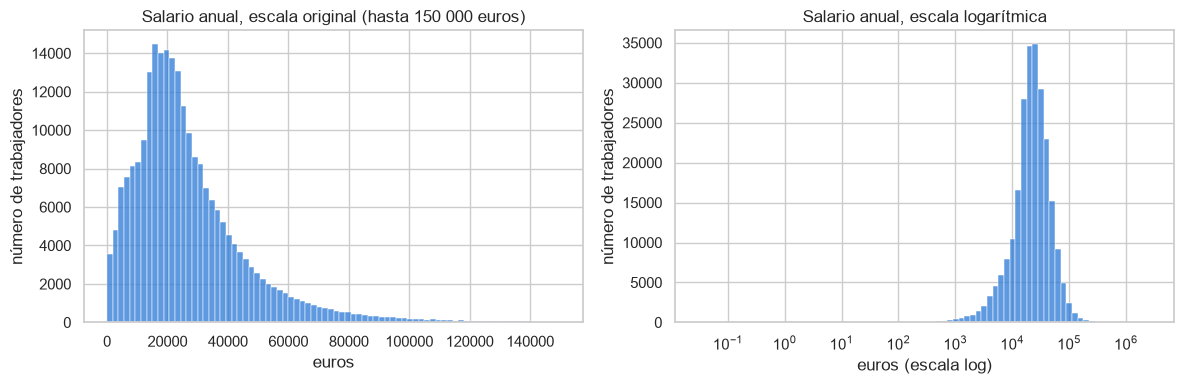

In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

# A la izquierda limitamos el eje a 150 000 euros: el máximo (2,8 millones) aplastaría el gráfico
sns.histplot(df.loc[df["RETRINOIN"] < 150_000, "RETRINOIN"], bins=80, ax=ejes[0], color="#2a78d6")
ejes[0].set_title("Salario anual, escala original (hasta 150 000 euros)")
ejes[0].set_xlabel("euros")
ejes[0].set_ylabel("número de trabajadores")

sns.histplot(df.loc[df["RETRINOIN"] > 0, "RETRINOIN"], bins=80, ax=ejes[1], color="#2a78d6", log_scale=True)
ejes[1].set_title("Salario anual, escala logarítmica")
ejes[1].set_xlabel("euros (escala log)")
ejes[1].set_ylabel("número de trabajadores")
plt.tight_layout()
plt.show()

**Lectura.** La distribución es asimétrica: la mayoría de los salarios se concentran en la parte baja y hay una cola larga hacia la derecha. La media es mayor que la mediana. En escala logarítmica la forma se acerca a una campana. Guardamos este dato: la asimetría va a afectar a la regresión lineal, y en el tema siguiente será la razón para introducir otros modelos.

### 2.2 Limpieza

Tomamos dos decisiones y las dejamos escritas, porque afectan a los resultados:

1. Eliminamos los salarios iguales a cero. Corresponden a registros sin actividad retribuida en el año y no aportan información sobre lo que queremos explicar.
2. Recortamos el 1 por ciento de salarios más altos. Son casos extremos que dominan el error cuadrático y dificultan el aprendizaje. Es una decisión discutible, pero es transparente y reproducible.

Además, para que las celdas se ejecuten con rapidez, trabajaremos con una muestra aleatoria de 10 000 trabajadores. El fichero completo tiene 240 490, y puede usarse entero si se dispone de tiempo.

In [7]:
tope = df["RETRINOIN"].quantile(0.99)
limpio = df[(df["RETRINOIN"] > 0) & (df["RETRINOIN"] <= tope)]
print(f"Tope (percentil 99): {tope:,.0f} euros")
print(f"Filas tras la limpieza: {len(limpio):,} (descartadas {len(df) - len(limpio):,})")

# sample() extrae filas al azar; random_state fija la semilla, como set.seed() en R
datos = limpio.sample(n=10000, random_state=SEMILLA).reset_index(drop=True)
print("Muestra de trabajo:", datos.shape)

Tope (percentil 99): 113,801 euros
Filas tras la limpieza: 237,353 (descartadas 3,137)
Muestra de trabajo: (10000, 56)


### 2.3 Salario por sexo

Un primer cruce descriptivo. En la encuesta, `SEXO` toma el valor 1 para hombres y 6 para mujeres. Con `map()` sustituimos los códigos por etiquetas legibles (en R se haría con `factor(..., labels = ...)`), y con `groupby()` calculamos resúmenes por grupo (como `group_by() + summarise()` de `dplyr`).

In [8]:
datos["SEXO_etq"] = datos["SEXO"].map({1: "Hombre", 6: "Mujer"})
datos.groupby("SEXO_etq")["RETRINOIN"].agg(["count", "mean", "median"]).round(0)

,count,mean,median
SEXO_etq,,,
Hombre,5490,28971.0,24360.0
Mujer,4510,24259.0,19854.0


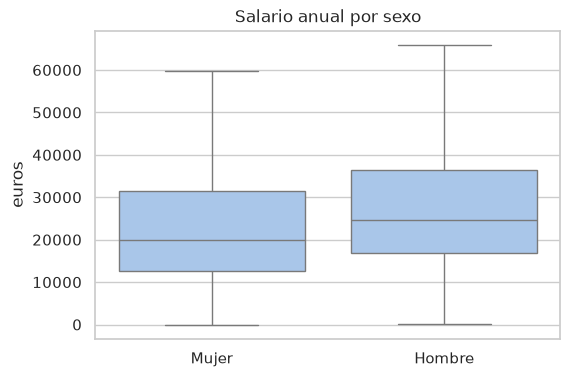

In [9]:
fig, eje = plt.subplots(figsize=(6, 4))
sns.boxplot(data=datos, x="SEXO_etq", y="RETRINOIN", ax=eje, showfliers=False, color="#9ec5f4")
eje.set_title("Salario anual por sexo")
eje.set_xlabel("")
eje.set_ylabel("euros")
plt.show()

### Ejercicio 1. Salario por tipo de jornada y por nivel de estudios

1. La variable `TIPOJOR` codifica el tipo de jornada: 1 es jornada completa y 2 jornada parcial. Crea una columna `JORNADA_etq` con esas etiquetas.
2. Calcula el salario medio y mediano por jornada.
3. Dibuja un diagrama de caja del salario por jornada.
4. Repite el diagrama de caja para `ESTU`, el nivel de estudios (a mayor código, mayor nivel).
5. Escribe en un comentario qué relación observas entre estudios y salario.

In [10]:
# Escribe aquí tu solución




## 3. Qué variables pueden ser predictores

El fichero tiene 56 variables, pero no todas sirven para predecir el salario. Distinguimos tres grupos.

| Grupo | Qué es | Se usa como predictor |
|---|---|---|
| Respuesta | `RETRINOIN` | No, es lo que predecimos |
| Componentes del salario | Variables que forman parte del propio salario anual o se calculan a partir de él | No |
| Características del trabajador y del puesto | Sexo, estudios, ocupación, sector, antigüedad, jornada, región... | Sí |

### Por qué no usamos los componentes del salario

`SALBASE` (salario base mensual), `COMSAL` (complementos), `EXTRAORM` (pagas extraordinarias), `GEXTRA`, `BASE`, `COTIZA` y otras son piezas que suman para formar el salario anual. Predecir `RETRINOIN` con ellas es como predecir el total de un ticket de compra conociendo el precio de cada producto: el ajuste sería casi perfecto, y no serviría de nada. En una situación real, por ejemplo al estimar el salario de un puesto antes de fijarlo, no dispondríamos de esos componentes.

A este problema se le llama **fuga de información** (*data leakage*): el modelo aprende de información que en la práctica no estaría disponible en el momento de predecir. Es uno de los errores más frecuentes en predicción y conviene detectarlo antes de ajustar nada.

También dejamos fuera:

- Los identificadores `IDENCCC` y `ORDENTRA`: no contienen información que se pueda generalizar.
- El factor de elevación `FACTOTAL`: es un peso del diseño de la encuesta, no una característica del trabajador.

### Predictores que sí usamos

Dos numéricas: `ANOANTI` (antigüedad en años) y `JAP` (horas de jornada pactada). El resto son categóricas, aunque estén codificadas con números.

In [9]:
RESPUESTA = "RETRINOIN"

# Componentes del salario o variables derivadas de él: quedan fuera
FUGA_SALARIAL = ["SALBASE", "COMSAL", "COMSALTT", "EXTRAORM", "PHEXTRA", "BASE", "GEXTRA",
                 "VESPNOIN", "VESPIN", "RETRIIN", "IRPFMES", "COTIZA"]
IDENTIFICADORES = ["IDENCCC", "ORDENTRA"]
PESO_MUESTRAL = ["FACTOTAL"]

# Predictores
PRED_CATEGORICOS = ["SEXO", "ESTU", "ANOS2", "TIPOCON", "TIPOJOR", "CNO1", "CNACE", "CONTROL",
                    "MERCADO", "REGULACION", "RESPONSA", "NUTS1", "TIPOPAIS", "ESTRATO2"]
PRED_NUMERICOS = ["ANOANTI", "JAP"]
PREDICTORES = PRED_CATEGORICOS + PRED_NUMERICOS

print("Predictores categóricos:", len(PRED_CATEGORICOS))
print("Predictores numéricos:  ", len(PRED_NUMERICOS))

Predictores categóricos: 14
Predictores numéricos:   2


### 3.1 Comprobación empírica de la fuga

Comparemos la correlación con el salario de dos predictores legítimos y de tres componentes salariales.

In [10]:
for v in ["ANOANTI", "JAP", "SALBASE", "COMSAL", "GEXTRA"]:
    r = datos[v].corr(datos["RETRINOIN"])
    grupo = "componente del salario" if v in FUGA_SALARIAL else "predictor legítimo"
    print(f"corr(RETRINOIN, {v:8s}) = {r:5.2f}   {grupo}")

corr(RETRINOIN, ANOANTI ) =  0.37   predictor legítimo
corr(RETRINOIN, JAP     ) =  0.31   predictor legítimo
corr(RETRINOIN, SALBASE ) =  0.61   componente del salario
corr(RETRINOIN, COMSAL  ) =  0.68   componente del salario
corr(RETRINOIN, GEXTRA  ) =  0.60   componente del salario


Los componentes salariales tienen correlaciones mucho más altas. Un modelo que los usara parecería excelente y sería inútil.

### 3.2 Construir la matriz de predictores y la respuesta

En R, `lm()` recibe una fórmula y un `data.frame`, y se encarga por dentro de convertir los factores en variables indicadoras. En `scikit-learn` no hay fórmulas: el modelo recibe por un lado una tabla `X` con los predictores y por otro un vector `y` con la respuesta, y la conversión de categóricas la hacemos nosotros en el preprocesamiento (sección 5).

Convertimos ahora las columnas categóricas al tipo `category` de `pandas`, que es el análogo de `factor` en R.

In [11]:
X = datos[PREDICTORES].copy()
y = datos[RESPUESTA]

for col in PRED_CATEGORICOS:
    X[col] = X[col].astype("category")

# Comprobación: ningún componente salarial se ha colado entre los predictores
assert not set(FUGA_SALARIAL) & set(X.columns)
print("X:", X.shape, "  y:", y.shape)
X.dtypes

X: (10000, 16)   y: (10000,)


SEXO          category
ESTU          category
ANOS2         category
TIPOCON       category
TIPOJOR       category
CNO1          category
CNACE         category
CONTROL       category
MERCADO       category
REGULACION    category
RESPONSA      category
NUTS1         category
TIPOPAIS      category
ESTRATO2      category
ANOANTI          int64
JAP              int64
dtype: object

## 4. Partición en entrenamiento y prueba

Para saber si un modelo predice bien necesitamos evaluarlo con datos que no haya visto. Por eso, antes de hacer nada más, separamos:

- un conjunto de **entrenamiento** (75 por ciento), con el que se ajusta el modelo, y
- un conjunto de **prueba** (25 por ciento), reservado para medir el error al final.

El orden importa. Cualquier cálculo que use los datos (medias para escalar, categorías presentes, imputaciones) debe hacerse solo con el conjunto de entrenamiento. Si se hiciera con todos los datos, información del conjunto de prueba se filtraría al modelo y la evaluación sería optimista. Es otra forma de fuga de información, más sutil que la de la sección 3.

`train_test_split()` devuelve cuatro objetos, en este orden: predictores de entrenamiento, predictores de prueba, respuesta de entrenamiento, respuesta de prueba.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEMILLA)
print("Entrenamiento:", X_train.shape, "  Prueba:", X_test.shape)

Entrenamiento: (7500, 16)   Prueba: (2500, 16)


## 5. Preprocesamiento: dejar los datos como los necesita el modelo

Un modelo de `scikit-learn` solo acepta números. Antes de ajustar la regresión hay que:

- convertir cada variable categórica en un conjunto de columnas indicadoras (0/1), una por categoría, lo que en R hace `model.matrix()` automáticamente y aquí se llama *one-hot encoding*;
- escalar las variables numéricas, es decir, restar la media y dividir por la desviación típica (`scale()` en R), para que todas estén en unidades comparables; en la regresión lineal esto no cambia las predicciones, pero es una buena costumbre porque otros modelos sí lo necesitan;
- decidir qué hacer con valores ausentes, si los hubiera, en nuestro caso imputar la mediana o la categoría más frecuente.

Podríamos hacer estas tres cosas a mano sobre `X_train` y repetirlas sobre `X_test`. Es propenso a errores: hay que recordar usar las medias del entrenamiento, no las de prueba, y aplicar exactamente las mismas categorías. `scikit-learn` resuelve esto con dos herramientas que conviene entender bien porque aparecerán en todo el curso.

### 5.1 La idea central: `fit` y `transform`

Todo objeto de preprocesamiento de `scikit-learn` tiene dos métodos:

- `fit(X_train)`: **aprende** lo que necesita de los datos de entrenamiento. Un escalador aprende la media y la desviación típica de cada columna; un codificador *one-hot* aprende qué categorías existen.
- `transform(X)`: **aplica** lo aprendido a cualquier tabla, sea de entrenamiento o de prueba.

Los modelos siguen el mismo esquema: `fit(X_train, y_train)` ajusta y `predict(X)` predice. Esta uniformidad es la razón por la que en Python se puede cambiar de modelo modificando una línea.

Veámoslo con un escalador sobre las dos variables numéricas.

In [13]:
escalador = StandardScaler()
escalador.fit(X_train[PRED_NUMERICOS])            # aprende medias y desviaciones en entrenamiento

print("Medias aprendidas:      ", escalador.mean_.round(2))
print("Desviaciones aprendidas:", escalador.scale_.round(2))

# Aplica esas mismas medias y desviaciones al conjunto de prueba
X_test_num_escalado = escalador.transform(X_test[PRED_NUMERICOS])
print("\nPrimeras filas de prueba, escaladas:")
print(X_test_num_escalado[:3].round(2))

Medias aprendidas:       [  10.93 1606.79]
Desviaciones aprendidas: [ 10.34 336.53]

Primeras filas de prueba, escaladas:
[[-1.06  0.69]
 [-0.96  0.27]
 [-0.86 -3.41]]


Y ahora un codificador *one-hot* sobre una categórica. Fíjate en que cada categoría se convierte en una columna.

In [14]:
codificador = OneHotEncoder(sparse_output=False)
codificador.fit(X_train[["TIPOJOR"]])

print("Categorías vistas en entrenamiento:", codificador.categories_[0])
print("Nombres de las columnas creadas:  ", codificador.get_feature_names_out())
print("\nPrimeras filas de prueba, codificadas:")
print(codificador.transform(X_test[["TIPOJOR"]])[:5])

Categorías vistas en entrenamiento: [1 2]
Nombres de las columnas creadas:   ['TIPOJOR_1' 'TIPOJOR_2']

Primeras filas de prueba, codificadas:
[[1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]


### 5.2 `ColumnTransformer`: un tratamiento distinto para cada grupo de columnas

Tenemos dos grupos de columnas que necesitan tratamientos distintos. `ColumnTransformer` es una lista de instrucciones del tipo "a estas columnas aplícales esto". Cada instrucción es una terna `(nombre, transformador, lista de columnas)`. El nombre es una etiqueta libre que sirve para identificar el paso.

Con `OneHotEncoder` usamos dos opciones que conviene conocer:

- `handle_unknown="ignore"`: si en prueba aparece una categoría que no estaba en entrenamiento, se codifica como todo ceros en lugar de dar error.
- `min_frequency=0.01`: las categorías que aparecen en menos del 1 por ciento de las filas se agrupan en una sola columna "infrecuente". Evita columnas casi vacías en variables con muchos niveles, como el sector (`CNACE`).

In [15]:
preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), PRED_NUMERICOS),
        ("categoricas", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False),
         PRED_CATEGORICOS),
    ],
    remainder="drop",   # cualquier columna no mencionada se descarta
)

preprocesador.fit(X_train)
X_train_prep = preprocesador.transform(X_train)

print("Antes del preprocesamiento:", X_train.shape)
print("Después:                   ", X_train_prep.shape)
print("\nAlgunas columnas resultantes:")
print(preprocesador.get_feature_names_out()[:12])

Antes del preprocesamiento: (7500, 16)
Después:                    (7500, 88)

Algunas columnas resultantes:
['numericas__ANOANTI' 'numericas__JAP' 'categoricas__SEXO_1'
 'categoricas__SEXO_6' 'categoricas__ESTU_2' 'categoricas__ESTU_3'
 'categoricas__ESTU_4' 'categoricas__ESTU_5' 'categoricas__ESTU_6'
 'categoricas__ESTU_7' 'categoricas__ESTU_infrequent_sklearn'
 'categoricas__ANOS2_2']


**Lectura.** De 16 variables pasamos a un número mayor de columnas, todas numéricas: las dos numéricas escaladas más una columna indicadora por cada categoría (o grupo de categorías infrecuentes). Esto es exactamente lo que `lm()` construye por dentro en R con `model.matrix()`, con una diferencia: aquí no se elimina una categoría de referencia, porque `LinearRegression` gestiona la colinealidad y porque otros modelos del curso no la necesitan.

### 5.3 `Pipeline`: encadenar preprocesamiento y modelo

Un `Pipeline` es una secuencia de pasos con nombre, donde cada paso recibe la salida del anterior. El último paso es el modelo. La ventaja es que el objeto completo se comporta como un único modelo: `fit(X_train, y_train)` ajusta el preprocesador con los datos de entrenamiento y a continuación el modelo con los datos ya transformados; `predict(X_test)` aplica el preprocesador (sin volver a ajustarlo) y luego predice.

Con esto, la regla "el preprocesamiento se aprende solo en entrenamiento" queda garantizada por construcción y no depende de que nos acordemos.

In [16]:
modelo_lineal = Pipeline(steps=[
    ("preprocesado", preprocesador),
    ("regresion", LinearRegression()),
])
modelo_lineal

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesado', ...), ('regresion', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float,

## 6. Regresión lineal

El modelo es el que conocéis: la media del salario se expresa como una combinación lineal de los predictores,

$$\mathbb{E}[\text{salario} \mid X] = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p.$$

En R escribiríamos `lm(RETRINOIN ~ ., data = train)`. Aquí ajustamos el `Pipeline` completo con una llamada a `fit`.

In [17]:
modelo_lineal.fit(X_train, y_train)
print("Modelo ajustado")

Modelo ajustado


### 6.1 Predicciones y evaluación en el conjunto de prueba

Con `predict()` obtenemos una predicción para cada fila de prueba. Para medir la calidad usamos tres medidas, todas calculadas comparando predicciones con valores reales de `y_test`:

- **R²**: proporción de la varianza del salario que explica el modelo. Es la misma medida que en R, pero calculada en datos de prueba, así que puede ser algo menor que la de `summary(lm)` en los datos de ajuste.
- **RMSE** (raíz del error cuadrático medio): error típico, en euros. Penaliza mucho los errores grandes.
- **MAE** (error absoluto medio): error medio en valor absoluto, en euros. Más fácil de interpretar y menos sensible a casos extremos.

In [18]:
pred_test = modelo_lineal.predict(X_test)

print(f"R2   : {r2_score(y_test, pred_test):.3f}")
print(f"RMSE : {root_mean_squared_error(y_test, pred_test):,.0f} euros")
print(f"MAE  : {mean_absolute_error(y_test, pred_test):,.0f} euros")

R2   : 0.576
RMSE : 11,697 euros
MAE  : 8,240 euros


### 6.2 Diagnóstico gráfico

Dos gráficos habituales: predicción frente a valor real, y residuos (real menos predicción) frente a predicción.

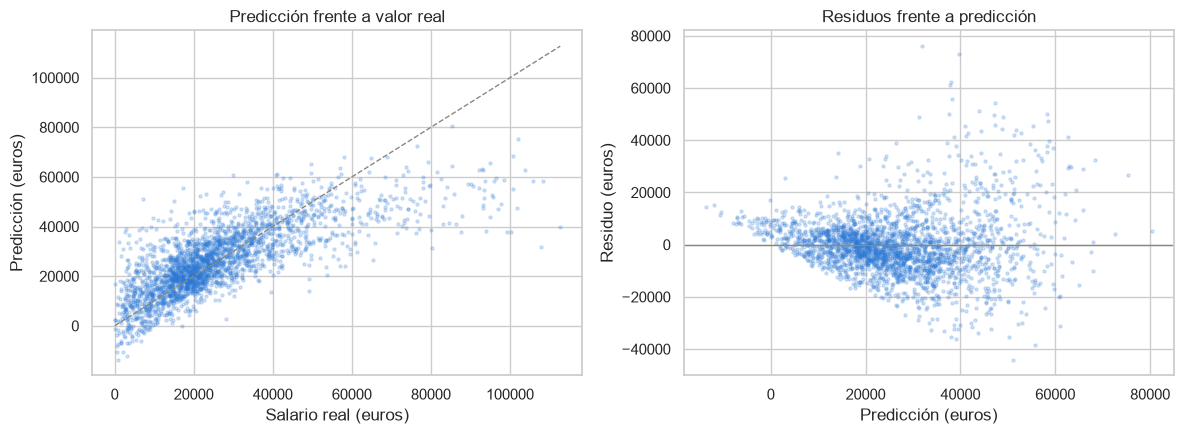

Predicciones negativas en prueba: 49


In [19]:
residuos = y_test - pred_test

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

ejes[0].scatter(y_test, pred_test, s=5, alpha=0.2, color="#2a78d6")
limites = [0, y_test.max()]
ejes[0].plot(limites, limites, color="#898781", lw=1, ls="--")
ejes[0].set_xlabel("Salario real (euros)")
ejes[0].set_ylabel("Predicción (euros)")
ejes[0].set_title("Predicción frente a valor real")

ejes[1].scatter(pred_test, residuos, s=5, alpha=0.2, color="#2a78d6")
ejes[1].axhline(0, color="#898781", lw=1)
ejes[1].set_xlabel("Predicción (euros)")
ejes[1].set_ylabel("Residuo (euros)")
ejes[1].set_title("Residuos frente a predicción")

plt.tight_layout()
plt.show()

print("Predicciones negativas en prueba:", int((pred_test < 0).sum()))

**Lectura.** El modelo capta la tendencia general, pero se observan dos problemas. Primero, algunas predicciones son negativas, algo imposible para un salario. Segundo, la dispersión de los residuos crece con el nivel de la predicción: el modelo se equivoca más, en euros, cuanto mayor es el salario. Ambos síntomas vienen de la asimetría que vimos en la sección 2 y son el punto de partida del tema siguiente, donde se cambia la forma de relacionar predictores y respuesta.

### 6.3 Los coeficientes

En R, `summary(lm)` muestra los coeficientes con sus errores estándar y contrastes. `LinearRegression` de `scikit-learn` está orientado a predecir, no a hacer inferencia: proporciona los coeficientes (`coef_`) y la constante (`intercept_`), pero no errores estándar ni p-valores. Para eso existe la librería `statsmodels`, que no usaremos en este cuaderno.

Extraemos los coeficientes del paso `regresion` del `Pipeline` y los emparejamos con los nombres de columna que genera el preprocesador.

In [20]:
nombres = modelo_lineal.named_steps["preprocesado"].get_feature_names_out()
coeficientes = pd.Series(modelo_lineal.named_steps["regresion"].coef_, index=nombres)

print(f"Constante: {modelo_lineal.named_steps['regresion'].intercept_:,.0f} euros\n")
print("Coeficientes de las variables numéricas (escaladas):")
print(coeficientes.filter(like="numericas").round(0).to_string())

print("\nCoeficientes de mayor valor absoluto:")
print(coeficientes.reindex(coeficientes.abs().sort_values(ascending=False).index).head(10).round(0).to_string())

Constante: 26,838 euros

Coeficientes de las variables numéricas (escaladas):
numericas__ANOANTI    3707.0
numericas__JAP        2248.0

Coeficientes de mayor valor absoluto:
categoricas__CNO1_A0                    14830.0
categoricas__CNO1_B0                    10034.0
categoricas__ESTU_7                      9192.0
categoricas__CNACE_P0                   -6907.0
categoricas__CNACE_C4                    6895.0
categoricas__CNACE_K0                    6330.0
categoricas__CNO1_C0                     5804.0
categoricas__ESTU_infrequent_sklearn    -5531.0
categoricas__CNO1_P0                    -4883.0
categoricas__CNO1_M0                    -4734.0


**Cómo leerlos.** Las variables numéricas están escaladas, así que su coeficiente es el cambio esperado en el salario, en euros, cuando la variable aumenta una desviación típica. Para las columnas indicadoras, el coeficiente es la diferencia esperada de salario entre esa categoría y el resto, manteniendo lo demás constante. Como no hay categoría de referencia, los coeficientes de una misma variable se interpretan comparándolos entre sí, no en valor absoluto.

### Ejercicio 2. Cuantificar la fuga de información

Vamos a comprobar con números por qué excluimos los componentes salariales.

1. Construye una lista de predictores numéricos que añada `SALBASE` a `PRED_NUMERICOS`.
2. Crea `X_fuga` a partir de `datos` con esos predictores más los categóricos, y haz la partición con la misma semilla.
3. Define un `ColumnTransformer` y un `Pipeline` análogos a los de la sección 5 y ajústalos.
4. Compara el R² en prueba con el del modelo legítimo. Explica en un comentario por qué el aumento es engañoso.

In [23]:
# Escribe aquí tu solución




### Ejercicio 3. Un modelo más sencillo

Ajusta una regresión lineal que use solo tres predictores: `ESTU`, `ANOANTI` y `TIPOJOR`. Necesitarás definir un nuevo `ColumnTransformer` con las listas de columnas reducidas y un nuevo `Pipeline`. Compara su R², RMSE y MAE en prueba con los del modelo completo. ¿Cuánta capacidad predictiva se pierde al quitar el resto de variables?

In [24]:
# Escribe aquí tu solución




## 7. Resumen

Lo que hemos hecho, en orden:

1. Cargar los datos con `pandas` y describirlos.
2. Estudiar la variable respuesta y tomar decisiones de limpieza documentadas.
3. Separar los predictores legítimos de las variables con fuga de información.
4. Partir en entrenamiento y prueba antes de cualquier otro cálculo.
5. Construir el preprocesamiento con `ColumnTransformer` y encadenarlo con el modelo en un `Pipeline`.
6. Ajustar una regresión lineal, evaluarla en prueba y diagnosticar sus limitaciones.

Los pasos 3, 4 y 5 se repetirán sin cambios en todos los temas del curso; lo que cambiará es el modelo del último paso del `Pipeline`.

### Correspondencias Python y R

| Tarea | Python | R |
|---|---|---|
| Cargar paquete | `import pandas as pd` | `library(dplyr)` |
| Leer datos | `pd.read_csv(ruta, sep="\t")` | `read.delim(ruta)` |
| Factor | `X[col].astype("category")` | `factor(x)` |
| Variables indicadoras | `OneHotEncoder` | `model.matrix()` |
| Escalar | `StandardScaler` | `scale()` |
| Partición | `train_test_split` | `sample()` o `rsample::initial_split()` |
| Regresión lineal | `LinearRegression().fit(X, y)` | `lm(y ~ ., data)` |
| Predecir | `modelo.predict(X_nuevo)` | `predict(modelo, newdata)` |
| R² | `r2_score(y, pred)` | `summary(modelo)$r.squared` |